# Emprego formal e arrecadação andam juntos em Uberlândia?

Duas séries que aparecem separadas nas análises 02 e 03, lado a lado:

- Saldo de empregos formais (admissões menos desligamentos, CAGED, com os ajustes oficiais);
- Receita tributária do município (IPTU, ISS, ITBI e outros impostos, do RREO que a prefeitura envia ao Tesouro).

A janela é 2022 a 2025, porque o saldo oficial do CAGED com ajustes só está publicado de forma consolidada para esses anos.

## Preparando os dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("dados/emprego_arrecadacao.csv")
df["receita_mi"] = df["receita_tributaria_reais"] / 1e6
df

,ano,saldo_empregos_caged,receita_tributaria_reais,receita_mi
0,2022,4937,8.446543e+08,844.654307
1,2023,4309,9.837350e+08,983.734955
2,2024,4093,1.109407e+09,1109.407117
3,2025,1937,1.243428e+09,1243.427581


## As duas séries no mesmo gráfico

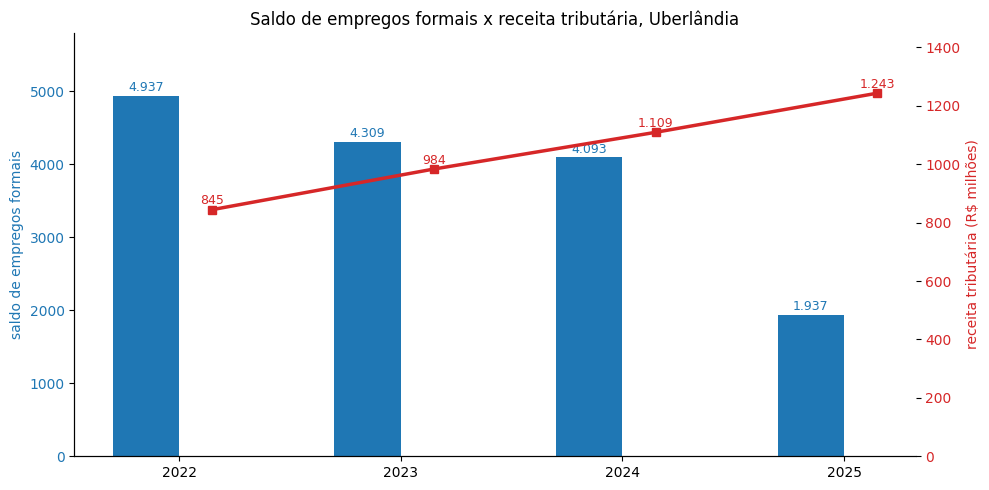

In [2]:
fig, ax1 = plt.subplots()
b = ax1.bar(df["ano"] - 0.15, df["saldo_empregos_caged"], width=0.3, color="#1f77b4", label="Saldo de empregos (CAGED)")
ax1.set_ylabel("saldo de empregos formais", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
for r, v in zip(df["ano"], df["saldo_empregos_caged"]):
    ax1.text(r - 0.15, v + 60, f"{v:,.0f}".replace(",", "."), ha="center", fontsize=9, color="#1f77b4")
ax2 = ax1.twinx()
ax2.spines["top"].set_visible(False)
ax2.plot(df["ano"] + 0.15, df["receita_mi"], marker="s", color="#d62728", linewidth=2.5, label="Receita tributária")
ax2.set_ylabel("receita tributária (R$ milhões)", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
for r, v in zip(df["ano"], df["receita_mi"]):
    ax2.text(r + 0.15, v + 18, f"{v:,.0f}".replace(",", "X").replace(".", ",").replace("X", "."),
             ha="center", fontsize=9, color="#d62728")
ax1.set_title("Saldo de empregos formais x receita tributária, Uberlândia")
ax1.set_xticks(df["ano"])
ax1.set_ylim(0, 5800)
ax2.set_ylim(0, 1450)
plt.tight_layout()
plt.savefig("grafico_emprego_arrecadacao.png", dpi=150)
plt.show()

## O que aparece

Os dois indicadores contam histórias diferentes no curto prazo:

- O saldo de empregos caiu a cada ano: de 4.937 em 2022 para 1.937 em 2025.
- A receita tributária subiu a cada ano: de R$ 844,7 milhões em 2022 para R$ 1,24 bilhão em 2025.

Ou seja: mesmo com o mercado de trabalho formal criando menos vagas, a arrecadação continuou crescendo. Duas explicações ajudam a entender: a receita tributária está em valores correntes (sem descontar a inflação, que acumulou bastante no período), e impostos como ISS e IPTU dependem de atividade e valores de mercado, não diretamente de quantas vagas formais foram criadas naquele ano.

## Ressalvas

- Receita tributária em valores correntes, sem deflacionar.
- O saldo do CAGED usado aqui é o oficial com ajustes, divulgado no boletim de emprego da UFU e na imprensa a partir do Ministério do Trabalho; ele pode divergir um pouco da soma dos microdados mensais, que só cobrem os registros dentro do prazo.
- Correlação entre as duas séries em quatro pontos não diz nada sobre causalidade. O gráfico serve para ver o ritmo de cada uma, não para provar que uma puxa a outra.

## Fontes

- CAGED (saldos oficiais com ajustes): Boletim do Emprego em Uberlândia, IERI/UFU, edições de dezembro de 2023 e 2024 (https://www.ieri.ufu.br), Diário de Uberlândia para 2022 e g1 Triângulo Mineiro para 2025, ambos citando o CAGED.
- Receita tributária: SICONFI/Tesouro Nacional, RREO 6º bimestre, anexo 01 (https://apidatalake.tesouro.gov.br/ords/siconfi/tt/rreo, ente 3170206).

O CSV em `dados/` tem os valores usados.